In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

In [2]:
P=2
vol=2
alpha=0.001
sigma=50499999.99999999
mur=1
mu0=4*np.pi*1e-7

In [3]:
# Select directory
#directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e1-1e8_40_el_12484_ord_"+str(P)
#directory="Results/OCC_sphere_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_500_el_18237_ord_4_POD_30_1e-6"
#directory="Results/OCC_sphere_prism_4_eigen/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_500_el_18237_ord_"+str(P)
# 0 layers
#directory="/home/pdl11/Coding/MPT_calculator/July2026/MPT-Calculator/Results/OCC_dualbar/al_0.001_mu_1,1_sig_1e6,1e8/1e-3-1e12_500_el_57195_ord_"+str(P)
directory="/home/pdl11/Coding/MPT_calculator/July2026/MPT-Calculator/Results/OCC_dualbar/al_0.001_mu_1,1_sig_1e6,1e8/1e-3-1e12_500_el_17683_ord_"+str(P)


ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')



directory="/home/pdl11/Coding/MPT_calculator/July2026/MPT-Calculator/Results/OCC_dualbar/al_0.001_mu_1,1_sig_1e6,1e8/1e-3-1e12_3000_el_57195_ord_3_POD_50_1e-6"
Omegapod=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArraypod= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvaluespod=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minfpod= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0pod= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')


(174, 3)
[1.24908477e-16 1.24908477e-16 1.24908477e-16]


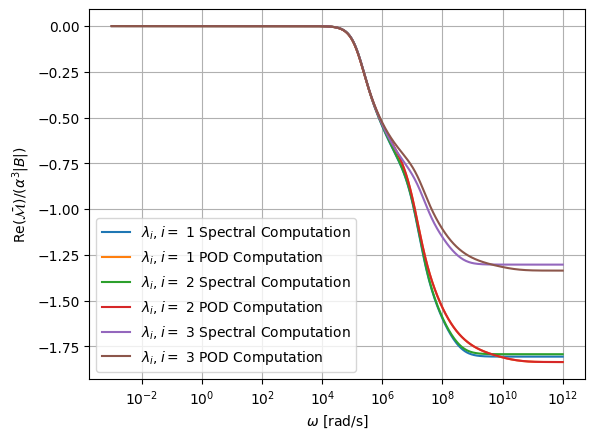

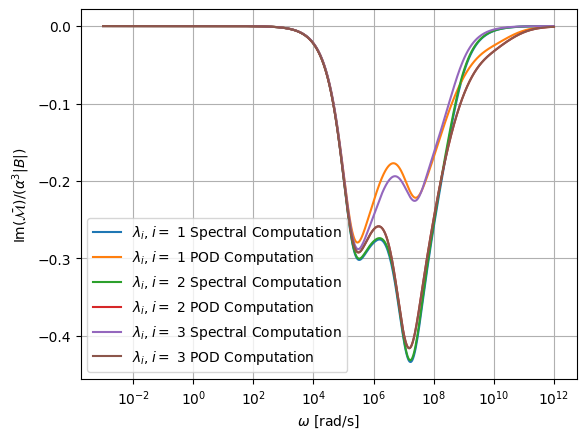

In [6]:
print(np.shape(xi))
#exactMPT=np.zeros(len(Omega),dtype=complex)
# Obtain exact MPT
#n=0
#for omega in Omega:
#    exactMPT[n]=exact_sphere(alpha, 0, mur, sigma, omega)
#    n+=1
# Obtain MPT from computed ck,xi
sMPT=np.zeros((len(Omega),3),dtype=complex)
dum,Q=np.linalg.eig(Minf)
lN0=np.diag(np.transpose(Q)@N0@Q)
print(lN0)
n=0
for omega in Omega:
    sMPT[n,:]=lN0[:]
    for j in range(3):
        for k in range(1,len(xi[:,j])):
            s=1j*omega
            sk=-xi[k,j]
            sMPT[n,j]+=-ck[k,j]*(s/(s-sk))
    n=n+1


plt.figure(1)
plt.figure(2)
scale=vol*alpha**3
for i in range(3):
    plt.figure(1)
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral Computation")
    #plt.semilogx(Omega,np.real(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    #plt.semilogx(Omega,np.real(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral2")
    plt.semilogx(Omegapod,np.real(Eigenvaluespod[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" POD Computation")
    
    
    plt.figure(2)
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral Computation")
    #plt.semilogx(Omega,-np.imag(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    #plt.semilogx(Omega,np.imag(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral2")
    plt.semilogx(Omegapod,-np.imag(Eigenvaluespod[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" POD Computation")


plt.figure(1)
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Re$(\bar{\cal M})/( \alpha^3|B|)$")
plt.legend()
plt.savefig("my_plots/dualbar_eigen/mpt_dualbar_real_eigen.pdf")

plt.figure(2)
plt.legend()
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Im$(\bar{\cal M})/(\alpha^3|B|)$")
plt.savefig("my_plots/dualbar_eigen/mpt_dualbar_imag_eigen.pdf")



In [5]:
Npoles=20
# Get the exact td step response (Method 2)
_, A2 = exactA(time, sigma, mur*mu0, alpha, Npoles)
l_td_exact_step = A2

# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=1
plt.semilogx(time, l_td_exact_step /scale , 'b-', label="Exact Step")
scale=2*np.pi*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(2\pi\alpha^3)$")



_, B2 = exactB(time, sigma, mur*mu0, alpha, Npoles)
l_td_exact_impulse = B2

plt.figure(2)
scale=l_td_exact_impulse[0]
plt.semilogx(time, l_td_exact_impulse / scale, 'b-', label="Exact Impulse")
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,"r--",label=r"Numerical impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(2\pi\alpha^3)$")

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_1858447/3432435502.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))
/tmp/user/10925/ipykernel_1858447/3432435502.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))


NameError: name 'exactA' is not defined

174
174
174


(3.8, 10.0)

<Figure size 640x480 with 0 Axes>

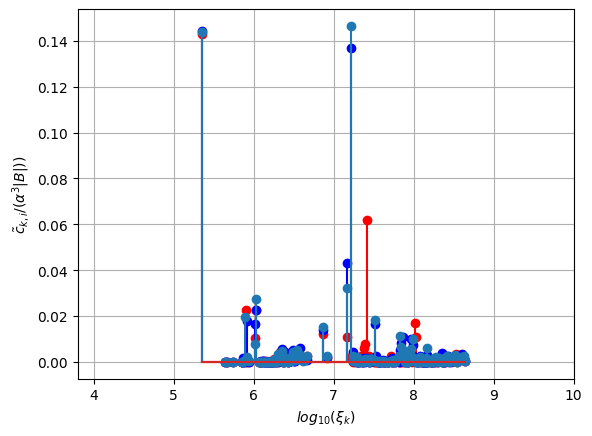

In [91]:
Npoles=20
#polesexact,ckexact=exactpoleres(sigma,mur*mu0,alpha,Npoles)
#print(polesexact,ckexact)
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    print(nfound)
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
    #plt.stem(np.log10(np.abs(polesexact)),ckexact)
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B|))$')

plt.grid()
plt.xlim(3.8,10)
#plt.legend()